# Freight rate assessment: data exploration

This notebook explores the Spotter development and prediction inputs. It does not train a model, fill predictions, or modify the source CSVs.

**Target:** `posted_rate` (total load rate in dollars). **Identifier:** `load_id` (excluded from model features).

Run cells from top to bottom in VS Code. Select a Python kernel with pandas, NumPy, matplotlib and IPython installed. If needed, run the installation command below in a separate notebook cell, then restart the kernel:

```python
%pip install "numpy>=1.26,<3" "pandas>=2.0,<3" "matplotlib>=3.8,<4" ipykernel
```

The notebook reserves the latest labeled calendar month for a proposed final holdout. Target exploration uses earlier development rows only. This boundary is a proposal, to be reviewed before model selection.


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True,
                     'grid.alpha': 0.2, 'axes.spines.top': False,
                     'axes.spines.right': False})
print({'python': sys.version.split()[0], 'pandas': pd.__version__,
       'numpy': np.__version__, 'matplotlib': matplotlib.__version__})


{'python': '3.10.20', 'pandas': '2.3.3', 'numpy': '2.2.6', 'matplotlib': '3.10.9'}


## 1. Find and load the project files

The file search supports running from either `Spotter/` or `Spotter/notebooks/`, and accepts the assignment's underscore filenames as well as the downloaded hyphen filenames. Set `PROJECT_DIR` explicitly if your kernel starts elsewhere.


In [3]:
PROJECT_DIR = None  # Example: Path('/Users/wijamuni/Projects/Spotter')
aliases = {
    'development': ['train-test.csv', 'train_test.csv'],
    'validation': ['validation.csv'],
    'template': ['validation-predictions-template.csv', 'validation_predictions_template.csv'],
    'december': ['december-chart-inputs.csv', 'december_chart_inputs.csv'],
}

def locate(root, names):
    return next((folder / name for folder in [root, root / 'data']
                 for name in names if (folder / name).is_file()), None)

candidates = ([Path(PROJECT_DIR).expanduser()] if PROJECT_DIR is not None
              else [Path.cwd(), *Path.cwd().parents, Path.home() / 'Projects' / 'Spotter'])
root = next((p for p in candidates if all(locate(p, names) for names in aliases.values())), None)
if root is None:
    raise FileNotFoundError('Set PROJECT_DIR to the Spotter folder containing all four CSV files.')
paths = {name: locate(root, names) for name, names in aliases.items()}
raw = {name: pd.read_csv(path) for name, path in paths.items()}
display(pd.DataFrame([{'dataset': name, 'rows': len(raw[name]),
                       'columns': raw[name].shape[1], 'file': str(path)}
                      for name, path in paths.items()]))


,dataset,rows,columns,file
0,development,48000,14,/Users/wijamuni/Projects/Spotter/train-test.csv
1,validation,12000,13,/Users/wijamuni/Projects/Spotter/validation.csv
2,template,12000,2,/Users/wijamuni/Projects/Spotter/validation-predictions-...
3,december,31,7,/Users/wijamuni/Projects/Spotter/december-chart-inputs.csv


## 2. Check the schema and submission identifiers

The unlabeled validation set contains the final 12,000 loads; it is not the labeled holdout used to measure accuracy. Blank prediction columns in the supplied templates are expected.


In [4]:
features = ['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat',
            'delivery_lon', 'distance', 'equipment', 'weight', 'date',
            'market_index', 'quote_signal']
required = {
    'development': ['load_id', *features, 'posted_rate'],
    'validation': ['load_id', *features],
    'template': ['load_id', 'predicted_rate'],
    'december': ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate'],
}
for name, columns in required.items():
    missing = set(columns) - set(raw[name].columns)
    if missing:
        raise ValueError(f'{name}: missing columns {sorted(missing)}')

expected_ids = {f'TE-{i:06d}' for i in range(1, 12001)}
checks = []
for name in ['validation', 'template']:
    ids = raw[name]['load_id']
    checks.append({'dataset': name, 'rows': len(ids), 'missing_ids': ids.isna().sum(),
                   'duplicate_ids': ids.duplicated().sum(),
                   'matches_expected_id_set': set(ids) == expected_ids})
display(pd.DataFrame(checks).set_index('dataset'))
assert all(len(raw[n]) == 12000 and raw[n].load_id.notna().all()
           and raw[n].load_id.is_unique and set(raw[n].load_id) == expected_ids
           for n in ['validation', 'template']), 'Submission IDs need investigation.'
assert list(raw['template'].columns) == required['template']
print('Validation IDs match the template:', set(raw['validation'].load_id) == set(raw['template'].load_id))
print('Development/validation ID overlap:', len(set(raw['development'].load_id) & set(raw['validation'].load_id)))
print('Template rates already populated:', raw['template'].predicted_rate.notna().sum())
display(raw['development'].head())


,rows,missing_ids,duplicate_ids,matches_expected_id_set
dataset,,,,
validation,12000,0,0,True
template,12000,0,0,True


Validation IDs match the template: True
Development/validation ID overlap: 0
Template rates already populated: 0


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 3. Parse types and audit missing values

Only in-memory copies are changed. Invalid numeric strings and non-finite values are reported, then represented as missing values. Imputation is deliberately deferred: learned fill values must be fitted within each training fold.


,dataset,column,invalid_numeric_strings,infinite_values,invalid_dates
0,development,pickup_lat,0.0,0.0,0.0
1,development,pickup_lon,0.0,0.0,0.0
2,development,delivery_lat,0.0,0.0,0.0
3,development,delivery_lon,0.0,0.0,0.0
4,development,distance,0.0,0.0,0.0
5,development,weight,0.0,0.0,0.0
6,development,market_index,0.0,0.0,0.0
7,development,quote_signal,0.0,0.0,0.0
8,development,posted_rate,0.0,0.0,0.0
9,development,date,0.0,0.0,0.0


,development_missing_pct,validation_missing_pct
date,0.00,0.00
delivery,0.00,0.00
delivery_lat,0.00,0.00
delivery_lon,0.00,0.00
distance,0.00,0.00
equipment,0.00,0.00
load_id,0.00,0.00
market_index,0.78,2.08
pickup,0.00,0.00
pickup_lat,0.00,0.00


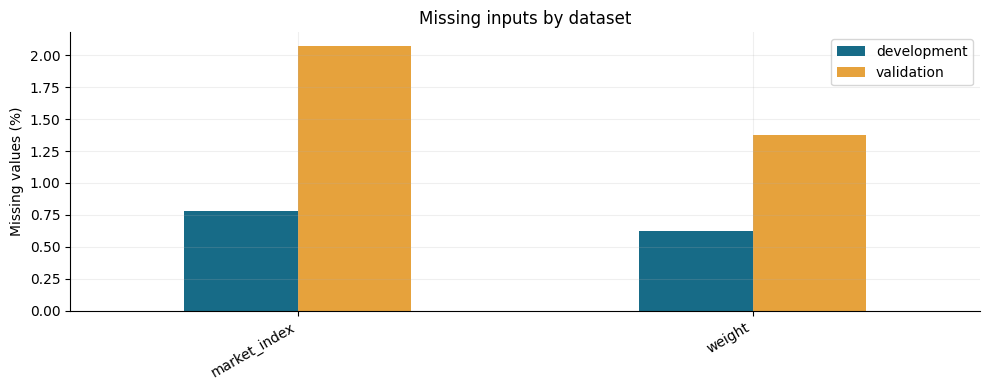

In [5]:
numeric_columns = ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
                   'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate']
frames, parsing = {}, []
for name in ['development', 'validation', 'december']:
    frame = raw[name].copy()
    for column in numeric_columns:
        if column not in frame:
            continue
        original = frame[column]
        numeric = pd.to_numeric(original, errors='coerce')
        parsing.append({'dataset': name, 'column': column,
                        'invalid_numeric_strings': int((original.notna() & numeric.isna()).sum()),
                        'infinite_values': int(np.isinf(numeric).sum())})
        frame[column] = numeric.replace([np.inf, -np.inf], np.nan)
    dates = pd.to_datetime(frame['date'], errors='coerce')
    parsing.append({'dataset': name, 'column': 'date',
                    'invalid_numeric_strings': None, 'infinite_values': None,
                    'invalid_dates': int((frame['date'].notna() & dates.isna()).sum())})
    frame['date'] = dates
    frames[name] = frame

development, validation, december = [frames[n] for n in ['development', 'validation', 'december']]
display(pd.DataFrame(parsing).fillna(0))
missing = pd.DataFrame({name: frames[name].isna().mean().mul(100)
                        for name in ['development', 'validation']}).fillna(0)
display(missing.rename(columns=lambda x: x + '_missing_pct').round(2))
affected = missing.loc[missing.max(axis=1) > 0]
if not affected.empty:
    affected.plot.bar(color=['#176B87', '#E6A23C'])
    plt.ylabel('Missing values (%)')
    plt.title('Missing inputs by dataset')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


## 4. Structural data-quality checks

These are flags for investigation, not automatic deletion rules. Valid coordinate ranges do not establish that coordinates correspond to their named cities. Repeated shipment features can represent legitimate repeated loads.


In [6]:
def quality_checks(frame):
    result = {
        'missing_load_id': frame.load_id.isna().sum(),
        'duplicate_load_id': frame.load_id.duplicated().sum(),
        'duplicate_full_rows': frame.duplicated().sum(),
        'repeated_feature_rows': frame.duplicated(subset=features).sum(),
        'missing_or_invalid_date': frame.date.isna().sum(),
        'nonpositive_distance': frame.distance.le(0).sum(),
        'nonpositive_weight': frame.weight.le(0).sum(),
        'latitude_out_of_range': ((frame.pickup_lat.abs() > 90) | (frame.delivery_lat.abs() > 90)).sum(),
        'longitude_out_of_range': ((frame.pickup_lon.abs() > 180) | (frame.delivery_lon.abs() > 180)).sum(),
    }
    for column in ['pickup', 'delivery', 'equipment']:
        s = frame[column].astype('string')
        result[f'{column}_blank'] = (s.isna() | s.str.strip().eq('')).sum()
        result[f'{column}_outer_whitespace'] = s.ne(s.str.strip()).sum()
    return pd.Series(result)

display(pd.DataFrame({n: quality_checks(frames[n]) for n in ['development', 'validation']}))
shared_hashes = pd.util.hash_pandas_object(development[features], index=False)
prediction_hashes = pd.util.hash_pandas_object(validation[features], index=False)
print('Validation rows with identical feature hashes in development:', prediction_hashes.isin(shared_hashes).sum())


,development,validation
missing_load_id,0,0
duplicate_load_id,0,0
duplicate_full_rows,0,0
repeated_feature_rows,0,0
missing_or_invalid_date,0,0
nonpositive_distance,0,0
nonpositive_weight,292,145
latitude_out_of_range,0,0
longitude_out_of_range,0,0
pickup_blank,0,0


Validation rows with identical feature hashes in development: 0


## 5. Date coverage and proposed evaluation boundary

If final prediction dates follow labeled dates, chronological evaluation is more representative than randomly mixing earlier and later shipments. Reserve the final labeled calendar month before comparing models. Use earlier rolling monthly folds for model selection. Do not use the reserved month's targets to tune features or hyperparameters.


,dataset,first_date,last_date,unique_dates
0,development,2025-01-01,2025-10-31,304
1,validation,2025-11-01,2025-12-31,61
2,december,2025-12-01,2025-12-31,31


,partition,rows,first_date,last_date
0,earlier development,43147,2025-01-01,2025-09-30
1,reserved holdout,4853,2025-10-01,2025-10-31


Final prediction dates strictly follow labeled dates: True


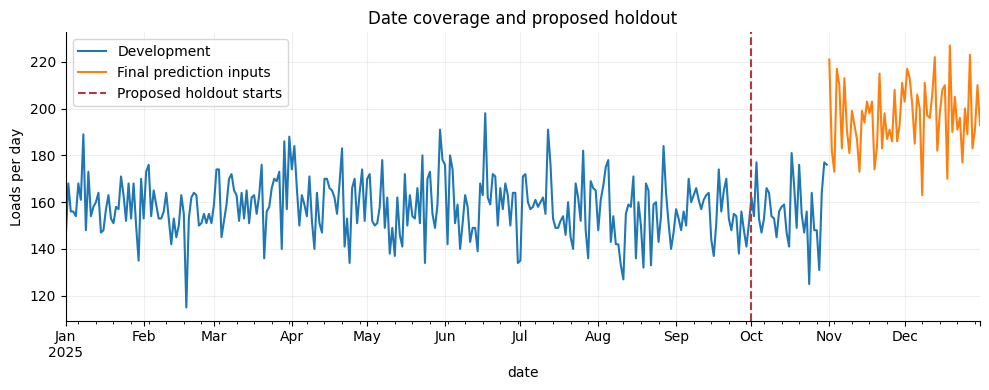

,evaluation_month,train_rows,evaluation_rows,training_dates
0,2025-07,28806,4912,before 2025-07-01
1,2025-08,33718,4759,before 2025-08-01
2,2025-09,38477,4670,before 2025-09-01


In [7]:
display(pd.DataFrame([{'dataset': n, 'first_date': frames[n].date.min(),
                       'last_date': frames[n].date.max(), 'unique_dates': frames[n].date.nunique()}
                      for n in ['development', 'validation', 'december']]))
if development.date.isna().any() or development.date.nunique() < 2:
    raise ValueError('Resolve missing dates or insufficient date coverage before a chronological split.')
HOLDOUT_START = development.date.max().to_period('M').start_time
exploration = development.loc[development.date < HOLDOUT_START].copy()
holdout = development.loc[development.date >= HOLDOUT_START].copy()
if exploration.empty or holdout.empty:
    raise ValueError('Choose an explicit holdout boundary; the automatic month split is unsuitable.')
display(pd.DataFrame([{'partition': n, 'rows': len(f), 'first_date': f.date.min(), 'last_date': f.date.max()}
                      for n, f in [('earlier development', exploration), ('reserved holdout', holdout)]]))
print('Final prediction dates strictly follow labeled dates:', validation.date.min() > development.date.max())
fig, ax = plt.subplots()
for name, frame in [('Development', development), ('Final prediction inputs', validation)]:
    frame.groupby('date').size().plot(ax=ax, label=name)
ax.axvline(HOLDOUT_START, color='#B33A3A', linestyle='--', label='Proposed holdout starts')
ax.set(ylabel='Loads per day', title='Date coverage and proposed holdout')
ax.legend()
plt.tight_layout()
plt.show()

folds = []
for month in sorted(exploration.date.dt.to_period('M').unique())[-3:]:
    start, end = month.start_time, (month + 1).start_time
    before = exploration.date < start
    during = exploration.date.ge(start) & exploration.date.lt(end)
    if before.any() and during.any():
        folds.append({'evaluation_month': str(month), 'train_rows': int(before.sum()),
                      'evaluation_rows': int(during.sum()), 'training_dates': f'before {start.date()}'})
display(pd.DataFrame(folds))


## 6. Explore the target using earlier development rows only

Inspect total rate and rate per mile. Large values may be valid long-distance shipments. Do not remove observations solely because they are in a distribution tail.


Earlier rows with missing target: 0
Earlier rows with nonpositive target: 0


,count,mean,std,min,1%,5%,50%,95%,99%,max
posted_rate,43147.0,2373.410,1481.686,57.220,329.300,600.921,2029.700,4945.670,5971.349,25533.000
rate_per_mile,43147.0,2.213,0.580,0.334,1.672,1.805,2.143,2.731,3.169,14.125
distance,43147.0,1136.968,728.275,70.000,123.046,236.900,954.700,2561.700,3029.208,3439.800
weight,42879.0,31030.065,9373.381,-47500.000,9894.580,17517.000,31435.000,44903.400,47500.000,47500.000
market_index,42815.0,1.098,0.170,0.676,0.781,0.835,1.083,1.370,1.409,1.468
quote_signal,43147.0,2.076,0.291,0.692,1.332,1.635,2.064,2.576,2.904,3.610


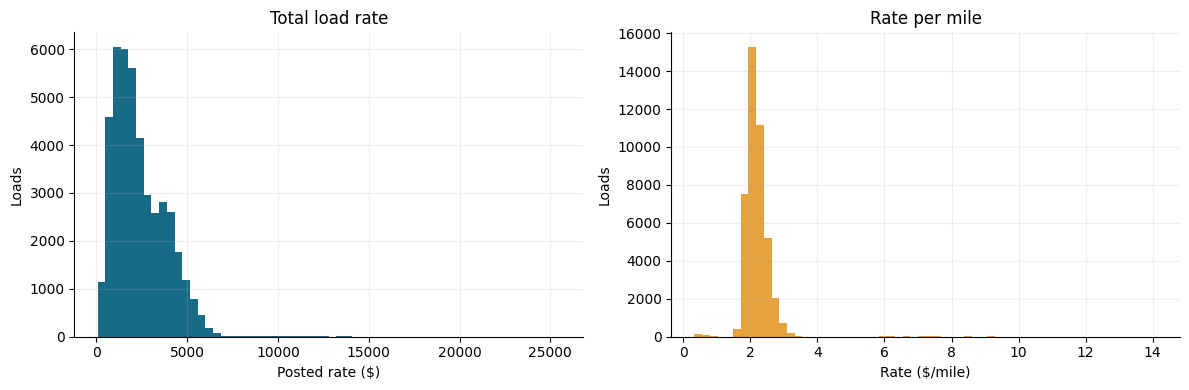

In [8]:
usable = exploration.posted_rate.gt(0) & exploration.distance.gt(0)
print('Earlier rows with missing target:', exploration.posted_rate.isna().sum())
print('Earlier rows with nonpositive target:', exploration.posted_rate.le(0).sum())
eda = exploration.loc[usable].copy()
eda['rate_per_mile'] = eda.posted_rate / eda.distance
display(eda[['posted_rate', 'rate_per_mile', 'distance', 'weight', 'market_index', 'quote_signal']]
        .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(eda.posted_rate, bins=60, color='#176B87')
axes[0].set(title='Total load rate', xlabel='Posted rate ($)', ylabel='Loads')
axes[1].hist(eda.rate_per_mile, bins=60, color='#E6A23C')
axes[1].set(title='Rate per mile', xlabel='Rate ($/mile)', ylabel='Loads')
plt.tight_layout()
plt.show()


## 7. Equipment, routes and relationships

Use aggregate summaries to identify useful features. Target-based route statistics, if later added to a model, must be computed within training folds rather than on the full dataset.


,loads,median_rate,median_distance,median_rate_per_mile
equipment,,,,
Dry Van,24457,1957.39,962.4,2.04
Flatbed,7835,2082.11,943.9,2.22
Reefer,10855,2181.88,946.1,2.31


,,loads,median_rate
pickup,delivery,,
Phoenix,Shreveport,38,3562.02
Richmond,Phoenix,37,5010.88
Shreveport,Hartford,36,2814.72
Lexington,Atlanta,36,557.58
Columbia,Oklahoma City,35,2321.66
Fort Wayne,Hartford,34,1726.87
Columbia,Montgomery,34,824.24
Fort Wayne,Philadelphia,34,1713.10
Oklahoma City,Atlanta,34,1925.24


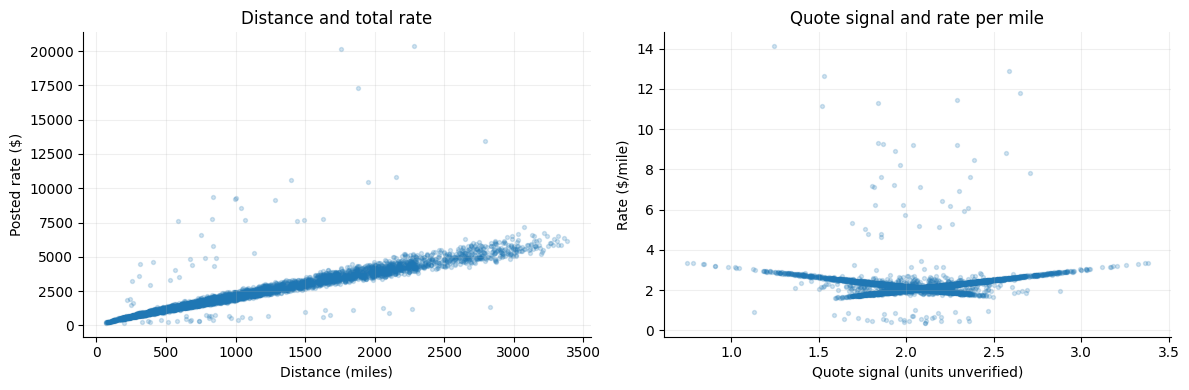

,posted_rate,rate_per_mile,distance,weight,market_index,quote_signal
posted_rate,1.000,-0.616,0.976,0.045,0.033,-0.123
rate_per_mile,-0.616,1.000,-0.733,0.192,0.205,0.208
distance,0.976,-0.733,1.000,0.006,-0.004,-0.147
weight,0.045,0.192,0.006,1.000,0.002,0.033
market_index,0.033,0.205,-0.004,0.002,1.000,-0.088
quote_signal,-0.123,0.208,-0.147,0.033,-0.088,1.000


In [9]:
display(eda.groupby('equipment', dropna=False).agg(
    loads=('posted_rate', 'size'), median_rate=('posted_rate', 'median'),
    median_distance=('distance', 'median'), median_rate_per_mile=('rate_per_mile', 'median')).round(2))
display(eda.groupby(['pickup', 'delivery']).agg(
    loads=('posted_rate', 'size'), median_rate=('posted_rate', 'median'))
    .sort_values('loads', ascending=False).head(15).round(2))
sample = eda.sample(min(len(eda), 5000), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(sample.distance, sample.posted_rate, s=8, alpha=0.2)
axes[0].set(xlabel='Distance (miles)', ylabel='Posted rate ($)', title='Distance and total rate')
axes[1].scatter(sample.quote_signal, sample.rate_per_mile, s=8, alpha=0.2)
axes[1].set(xlabel='Quote signal (units unverified)', ylabel='Rate ($/mile)', title='Quote signal and rate per mile')
plt.tight_layout()
plt.show()
display(eda[['posted_rate', 'rate_per_mile', 'distance', 'weight', 'market_index', 'quote_signal']]
        .corr(method='spearman').round(3))


## 8. Temporal behavior

Monthly aggregates can reflect changing route and equipment mixes as well as changing prices. Correlation and visible trends do not establish causation or guarantee future performance.


,loads,median_rate,median_rate_per_mile,median_distance
date,,,,
2025-01,4918,1915.20,2.03,950.85
2025-02,4337,1994.25,2.06,966.30
2025-03,5036,2022.92,2.14,954.60
2025-04,4819,2044.24,2.15,956.60
2025-05,4913,2065.51,2.19,953.00
2025-06,4783,2120.22,2.25,950.70
2025-07,4912,2059.14,2.19,955.70
2025-08,4759,2015.73,2.12,957.10
2025-09,4670,2057.13,2.16,954.40


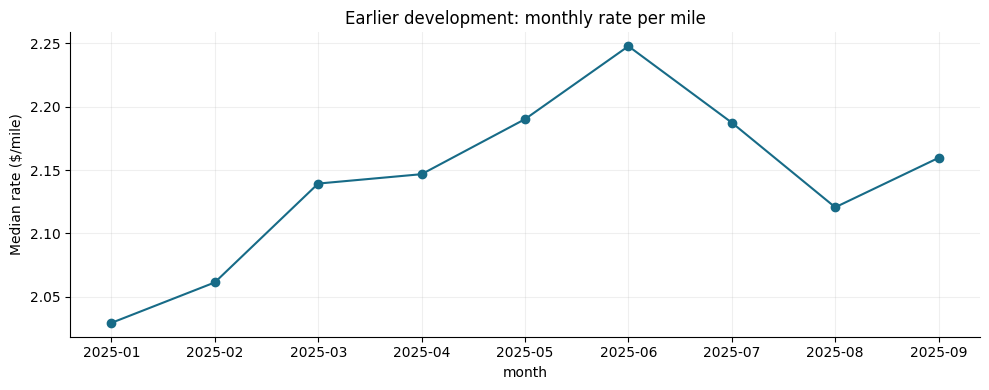

,loads,median_rate_per_mile
weekday,,
Monday,6134,2.12
Tuesday,6126,2.14
Wednesday,6223,2.16
Thursday,6152,2.17
Friday,6163,2.16
Saturday,6141,2.13
Sunday,6208,2.12


In [10]:
monthly = eda.groupby(eda.date.dt.to_period('M')).agg(
    loads=('posted_rate', 'size'), median_rate=('posted_rate', 'median'),
    median_rate_per_mile=('rate_per_mile', 'median'), median_distance=('distance', 'median'))
display(monthly.round(2))
monthly.assign(month=monthly.index.astype(str)).plot(
    x='month', y='median_rate_per_mile', marker='o', legend=False, color='#176B87')
plt.ylabel('Median rate ($/mile)')
plt.title('Earlier development: monthly rate per mile')
plt.tight_layout()
plt.show()
display(eda.assign(weekday=eda.date.dt.day_name()).groupby('weekday').agg(
    loads=('posted_rate', 'size'), median_rate_per_mile=('rate_per_mile', 'median'))
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).round(2))


## 9. Geographic consistency

Compare supplied road distance with the great-circle distance implied by the coordinates. A ratio well below one warrants investigation, but this check alone cannot identify whether distance or coordinates are wrong. Coordinate spread by city is a screening tool, not a geocoding verification.


In [11]:
def great_circle_miles(frame):
    lat1, lon1, lat2, lon2 = [np.radians(frame[c].to_numpy(dtype=float))
                             for c in ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon']]
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 3958.7613 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

geo = exploration.copy()
geo['great_circle_miles'] = great_circle_miles(geo)
geo['road_to_air_ratio'] = geo.distance / geo.great_circle_miles.where(geo.great_circle_miles > 1)
display(geo[['distance', 'great_circle_miles', 'road_to_air_ratio']].describe().T.round(2))
print('Rows with supplied distance below 90% of great-circle distance:', geo.road_to_air_ratio.lt(0.9).sum())
display(geo.loc[geo.road_to_air_ratio.lt(0.9),
                ['pickup', 'delivery', 'distance', 'great_circle_miles', 'road_to_air_ratio']].head(10))
display(geo.groupby('pickup').agg(latitude_min=('pickup_lat', 'min'), latitude_max=('pickup_lat', 'max'),
                                longitude_min=('pickup_lon', 'min'), longitude_max=('pickup_lon', 'max')).head(10))


,count,mean,std,min,25%,50%,75%,max
distance,43147.0,1136.97,728.28,70.00,551.70,954.70,1647.90,3439.80
great_circle_miles,43147.0,967.09,630.41,7.27,458.56,810.86,1411.19,2873.62
road_to_air_ratio,43147.0,1.19,0.14,1.06,1.16,1.18,1.20,9.64


Rows with supplied distance below 90% of great-circle distance: 0


,pickup,delivery,distance,great_circle_miles,road_to_air_ratio


,latitude_min,latitude_max,longitude_min,longitude_max
pickup,,,,
Albany,43.96975,43.96975,-71.05842,-71.05842
Albuquerque,35.39918,35.39918,-109.59792,-109.59792
Amarillo,33.17137,33.17137,-104.36789,-104.36789
Atlanta,34.84933,34.84933,-86.28940,-86.28940
Austin,29.39553,29.39553,-99.69780,-99.69780
Bakersfield,33.28832,33.28832,-116.67935,-116.67935
Baltimore,38.16908,38.16908,-72.74564,-72.74564
Baton Rouge,30.50134,30.50134,-92.65374,-92.65374
Birmingham,33.45794,33.45794,-86.72789,-86.72789


## 10. Compare final inputs with earlier development inputs

These comparisons use features only. They can reveal coverage gaps and distribution shifts, but they do not provide final prediction accuracy. Avoid repeatedly adapting a model to the final prediction set.


count       mean        std        min  \
dataset             feature                                                  
earlier_development distance      43147.0   1136.968    728.275     70.000   
                    weight        42879.0  31030.065   9373.381 -47500.000   
                    market_index  42815.0      1.098      0.170      0.676   
                    quote_signal  43147.0      2.076      0.291      0.692   
final_inputs        distance      12000.0   1141.773    732.334     70.000   
                    weight        11835.0  30506.636  10572.590 -47500.000   
                    market_index  11751.0      0.927      0.074      0.724   
                    quote_signal  12000.0      2.051      0.220      1.235   

                                        25%        50%        75%        max  
dataset             feature                                                   
earlier_development distance        551.700    954.700   1647.900   3439.800  
                    weight        25801.500  31435.000  37016.500  47500.000  
                    market_index      0.961      1.083      1.235      1.468  
                    quote_signal      1.901      2.064      2.234      3.610  
final_inputs        distance        556.100    953.600   1670.500   3325.700  
                    weight        25493.000  31193.000  36843.500  47500.000  
                    market_index      0.864      0.923      0.992      1.099  
                    quote_signal      1.903      2.051      2.200      2.896

,feature,unseen_categories,affected_rows
0,pickup,"[Allentown, Charlotte, Chicago, Jackson, Knoxville, Lare...",725
1,delivery,"[Allentown, Charlotte, Chicago, Jackson, Knoxville, Lare...",722
2,equipment,[],0


Final rows on routes unseen in earlier development: 1469


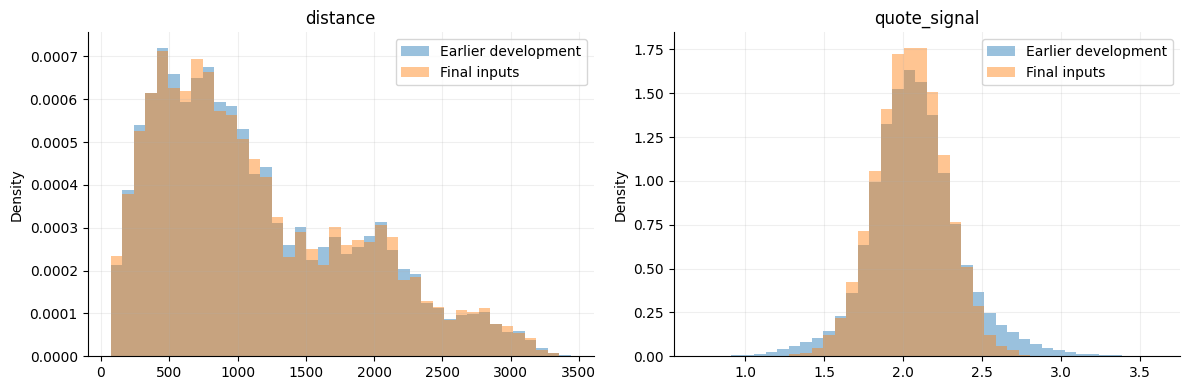

In [12]:
comparison_columns = ['distance', 'weight', 'market_index', 'quote_signal']
display(pd.concat({
    'earlier_development': exploration[comparison_columns].describe().T,
    'final_inputs': validation[comparison_columns].describe().T,
}, names=['dataset', 'feature']).round(3))
unseen = []
for column in ['pickup', 'delivery', 'equipment']:
    known = set(exploration[column].dropna())
    values = sorted(set(validation[column].dropna()) - known)
    unseen.append({'feature': column, 'unseen_categories': values,
                   'affected_rows': int((validation[column].notna() & ~validation[column].isin(known)).sum())})
display(pd.DataFrame(unseen))
known_routes = pd.MultiIndex.from_frame(exploration[['pickup', 'delivery']])
final_routes = pd.MultiIndex.from_frame(validation[['pickup', 'delivery']])
print('Final rows on routes unseen in earlier development:', int((~final_routes.isin(known_routes)).sum()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, column in zip(axes, ['distance', 'quote_signal']):
    combined = pd.concat([exploration[column], validation[column]]).dropna()
    bins = np.histogram_bin_edges(combined, bins=40)
    for label, frame in [('Earlier development', exploration), ('Final inputs', validation)]:
        ax.hist(frame[column].dropna(), bins=bins, density=True, alpha=0.45, label=label)
    ax.set(title=column, ylabel='Density')
    ax.legend()
plt.tight_layout()
plt.show()


## 11. Verify the December scenario

December has fewer features than the main model inputs. Do not manufacture observed market signals or quote signals. During model experiments, evaluate a documented missing-feature strategy or a separate model restricted to scenario-available inputs. If using a separate model, report that clearly.


In [13]:
expected_dates = set(pd.date_range('2025-12-01', '2025-12-31'))
december_checks = {
    'correct_column_order': list(raw['december'].columns) == required['december'],
    '31_rows': len(december) == 31,
    'all_december_dates_once': december.date.is_unique and set(december.date) == expected_dates,
    'pickup_fixed': december.pickup.eq('Lexington').all(),
    'delivery_fixed': december.delivery.eq('Fort Wayne').all(),
    'distance_fixed': np.isclose(december.distance, 360).all(),
    'equipment_fixed': december.equipment.eq('Dry Van').all(),
    'weight_fixed': np.isclose(december.weight, 32000).all(),
}
display(pd.Series(december_checks, name='passed'))
print('Features absent from December:', sorted(set(features) - set(december.columns)))
print('December rates already populated:', december.predicted_rate.notna().sum())
print('Earlier labeled loads on the December route:',
      int((exploration.pickup.eq('Lexington') & exploration.delivery.eq('Fort Wayne')).sum()))
assert all(december_checks.values()), 'Resolve December scenario discrepancies before prediction.'


correct_column_order       True
31_rows                    True
all_december_dates_once    True
pickup_fixed               True
delivery_fixed             True
distance_fixed             True
equipment_fixed            True
weight_fixed               True
Name: passed, dtype: bool

Features absent from December: ['delivery_lat', 'delivery_lon', 'market_index', 'pickup_lat', 'pickup_lon', 'quote_signal']
December rates already populated: 0
Earlier labeled loads on the December route: 28


## 12. Leakage review and implementation decisions

| Item | Decision or required follow-up |
|---|---|
| `load_id` | Keep for output matching; exclude from model features. |
| `posted_rate` | Target only; never an input. |
| `quote_signal` | Confirm how and when it was generated. A strong association alone is not proof of leakage. Compare models with and without it. |
| `market_index` | Confirm publication timing and availability at prediction time. |
| Missing weight/index | Fit imputers within each training fold; consider missingness indicators. |
| Geographic inconsistency | Investigate before relying on derived geographic features. Do not silently replace supplied coordinates. |
| Repeated loads | Determine whether repeated records are legitimate. Avoid copies of the same event appearing on both sides of evaluation. |
| Validation strategy | Review the proposed chronological holdout and use earlier rolling folds for tuning. |
| December features | Evaluate the reduced-input scenario before choosing its prediction strategy. |

### Next modeling notebook

1. Compare a training-only rate-per-mile baseline, a regularized linear model, and a categorical boosting model.
2. Report MAE and RMSE in total-rate dollars across chronological folds and shipment segments.
3. Select the approach without using reserved holdout targets for tuning.
4. Evaluate once on the reserved holdout, then refit on all eligible labeled data for submission.

### Findings to carry into the report

Use the executed tables and charts to record observed issues and their counts. Distinguish observed facts from hypotheses. This notebook does not establish model accuracy, feature availability, or the assignment provider's hidden scoring metric.
